## Exercise 3: Classifying activities with the PAMAP dataset we introduced in exercise 1, and use deep learning models

Previously in ex2, we used k-fold cross validation with a single participant's data and some simple features, with KNN or svm classifiers to detect the activities. In this exercise, we will reuse some of the codes from ex2, like loading the original data and balancing the samples. But we will do something different:


1.   First we will do leave-person-out validation instead of k-fold within a single person
2.   Intead of calculating features, we will use a deep neural network that feeds directly on the sensor data. Remember in the previous ex2 we need to first calculate abstract features for every sample window before giving the data to the classifier, because probabilisitc classifiers do not directly work on raw multichannel temporal data.
3.   Because training a neural network is different from fitting a classifier, as classifiers are mathematical representations and the current implementations give you the optimal result. Training a neural network 


For this exercise, you may have to refer to the tensorflow documentation. But we have placed as many comments as possible to guide you.
https://www.tensorflow.org/api_docs/python/tf/keras/layers

## Setting things up

First you should change the runtime type to GPU or TPU as the training would be faster.

add a shortcut to this following folder into your own google drive, so you don't need your local harddrive storage:

https://drive.google.com/drive/folders/10zzTzXgi9CvCEZNw6fG9fsIVjUXNijUu?usp=sharing

The first few lines of this code will mount your drive and read the data via the shortcut. You may need to authorize Colab to read your Drive, just follow the code's output instructions.

**Note** this folder is different from the last exercise folder. We've used the code from the last exercise and generated sliced windows with labels of the orginial dataset.



Contacts:

Bo Zhou: bo.zhou@dfki.de


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl
import itertools
import os
import shutil

from sklearn import neighbors, metrics
from sklearn.model_selection import (
    KFold,
    train_test_split,
    StratifiedKFold
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
print(os.listdir('/kaggle/input'))

DATASET_PATH = "/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset"

WINDOWSAMPLES_PATH = f"{DATASET_PATH}/WindowSamples"

if not os.path.exists("WindowSamples"):
    shutil.copytree(WINDOWSAMPLES_PATH, "WindowSamples")

print("WindowSamples copied successfully.")

['datasets']
WindowSamples copied successfully.


In [10]:
for root, dirs, files in os.walk("WindowSamples"):
    for file in files:
        print(file)

subject103.npz
subject108_multi.npz
subject105.npz
subject101.npz
subject104.npz
subject109_multi.npz
subject101_multi.npz
subject106_multi.npz
subject109.npz
subject108.npz
subject102_multi.npz
subject102.npz
subject103_multi.npz
subject105_multi.npz
subject107_multi.npz
subject104_multi.npz


In [11]:
def loadXy(ID):
  # Default file names
  fileName = 'WindowSamples/subject10'+str(ID)+'.npz'
  # Load data from numpy file
  data = np.load(fileName)
  # first lets see what's in the file
  #for k in data.iterkeys():
  #  print(k)
  # Skip the first column because it's timestamp
  X = data['arr_0'][:,:,1:4] 
  y = data['arr_1']
  return X, y

def balance_data(X, y):
  X_balanced = np.zeros((0, X.shape[1], X.shape[2])) #note we've changed from X_features to X for simplicity
  y_balanced = np.zeros((0)) 
  #first let's count how many samples are in each class.
  numClass = len(np.unique(y))
  m_counts = np.zeros((numClass))
  m_labels = np.unique(y)
  for i in range(0, numClass):
    m_counts[i] = int(sum(y==m_labels[i]))
  m_least = int(m_counts.min())
  for i in range(1, numClass): # note we are jumping over class 0 now
    rand_ind = np.random.permutation(int(m_counts[i]))
    m_subind = np.where(y==m_labels[i]) # this is the sub-index of the current class in the whole data file
    m_subind_balanced = m_subind[0][rand_ind[0:m_least]]
    # add the selected samples from the current class to the overall balanced dataset
    X_balanced = np.concatenate( (X_balanced, X[m_subind_balanced,:,:]) )
    y_balanced = np.concatenate( (y_balanced, y[m_subind_balanced]) )
  return X_balanced, y_balanced

def plot_confusion_matrix(cm, class_names):
  """
  You can mostly ignore this function
  Returns a matplotlib figure containing the plotted confusion matrix.
  Args:
  cm (array, shape = [n, n]): a confusion matrix of integer classes
  class_names (array, shape = [n]): String names of the integer classes
  """
  figure = plt.figure(figsize=(len(class_names)/2, len(class_names)/2))
  plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
  acc = np.sum( cm * np.eye(len(class_names)) ) / np.sum(cm)

  plt.title("CM , acc:"+str(round(acc,4)))
  plt.colorbar()
  tick_marks = np.arange(len(class_names))
  plt.xticks(tick_marks, class_names, rotation=45)
  plt.yticks(tick_marks, class_names)
  
  # Normalize the confusion matrix.
  cm = np.around(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], decimals=2)
  
  # Use white text if squares are dark; otherwise black.
  threshold = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      color = "white" if cm[i, j] > threshold else "black"
      plt.text(j, i, cm[i, j], horizontalalignment="center", color=color)

  #plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  #plt.show()
  return figure

def label2categorical(m_labels, numClass):
  m_labels_exp = np.zeros( ( len(m_labels), numClass ) )
  LUT = np.unique(m_labels) # to handel sporadically distributed labels
  for i in range (0, len(m_labels)):
      m_labels_exp[i, np.where(LUT==int(m_labels[i]))] = 1
  return m_labels_exp

In [12]:
X, y = loadXy(1)
X_test, y_test = balance_data(X, y)

print(X_test.shape)
print(y_test.shape)

# Check the activites performed by the subject
print(np.unique(y_test))
numClass = len(np.unique(y_test))

(3048, 200, 3)
(3048,)
[ 1.  2.  3.  4.  5.  6.  7. 12. 13. 16. 17. 24.]


In [18]:
print("X_train shape:", X_train.shape)
print("Sample shape:", X_train[0].shape)

X_train shape: (8322, 200, 3)
Sample shape: (200, 3)


In [19]:
X, y = loadXy(1)

print(X.shape)
print(y.shape)
print(X[0].shape)

(7413, 200, 3)
(7413,)
(200, 3)


In [20]:
data = np.load("WindowSamples/subject101.npz")

print(data['arr_0'].shape)
print(data['arr_1'].shape)

(7413, 200, 4)
(7413,)


In [22]:
# then we prepare the training data with persons 2-8
X_train = np.zeros((0,200,3)) # (sample, time, channel)
y_train = np.zeros((0))
for ID in range(2,8):
  print('ID: '+str(ID))
  X, y = loadXy(ID)
  X, y = balance_data(X,y)
  X_train = np.concatenate( (X_train, X) )
  y_train = np.concatenate( (y_train, y) )

print(X_train.shape)
print(y_train.shape)

# Check the activites performed by the subjects
print(np.unique(y_train))
numClass = len(np.unique(y_train))

ID: 2
ID: 3
ID: 4
ID: 5
ID: 6


FileNotFoundError: [Errno 2] No such file or directory: 'WindowSamples/subject106.npz'

**Now let's build the model**

In [23]:
def build_CNN(filters=20, kernel=3, dense=20, numClass=12):

    model = keras.models.Sequential([

        layers.Conv1D(
            filters=filters,
            kernel_size=kernel,
            padding='same',
            activation='relu',
            input_shape=(200,3)
        ),

        layers.MaxPooling1D(2),

        layers.BatchNormalization(),

        layers.Dropout(0.2),

        layers.Conv1D(
            filters=40,
            kernel_size=kernel,
            padding='same',
            activation='relu'
        ),

        layers.MaxPooling1D(2),

        layers.BatchNormalization(),

        layers.Dropout(0.2),

        layers.Flatten(),

        layers.Dense(
            dense,
            activation='relu'
        ),

        layers.Dropout(0.3),

        layers.Dense(
            numClass,
            activation='softmax'
        )
    ])

    return model

In [25]:
model = build_CNN()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train,
    label2categorical(y_train,numClass),
    epochs=100,
    batch_size=200,
    verbose=2
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 200, 20)        │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 100, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100, 20)        │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 100, 40)        │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 50, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 50, 40)         │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 50, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │        40,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,152 (168.56 KB)

 Trainable params: 43,032 (168.09 KB)

 Non-trainable params: 120 (480.00 B)

Epoch 1/100
42/42 - 4s - 100ms/step - accuracy: 0.2063 - loss: 0.6210
Epoch 2/100
42/42 - 1s - 35ms/step - accuracy: 0.2716 - loss: 0.4023
Epoch 3/100
42/42 - 1s - 35ms/step - accuracy: 0.3778 - loss: 0.2972
Epoch 4/100
42/42 - 1s - 35ms/step - accuracy: 0.4444 - loss: 0.2446
Epoch 5/100
42/42 - 2s - 36ms/step - accuracy: 0.5075 - loss: 0.2141
Epoch 6/100
42/42 - 1s - 35ms/step - accuracy: 0.5673 - loss: 0.1934
Epoch 7/100
42/42 - 1s - 35ms/step - accuracy: 0.6018 - loss: 0.1801
Epoch 8/100
42/42 - 1s - 34ms/step - accuracy: 0.6349 - loss: 0.1671
Epoch 9/100
42/42 - 1s - 35ms/step - accuracy: 0.6495 - loss: 0.1597
Epoch 10/100
42/42 - 1s - 34ms/step - accuracy: 0.6710 - loss: 0.1519
Epoch 11/100
42/42 - 1s - 35ms/step - accuracy: 0.6721 - loss: 0.1481
Epoch 12/100
42/42 - 2s - 36ms/step - accuracy: 0.6908 - loss: 0.1415
Epoch 13/100
42/42 - 1s - 34ms/step - accuracy: 0.7025 - loss: 0.1381
Epoch 14/100
42/42 - 3s - 61ms/step - accuracy: 0.7199 - loss: 0.1315
Epoch 15/100
42/42 - 1s - 34

Mine outcome, but you can design your own network however you like as long as it makes sense to you, and more importantly it compiles.



```
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
conv1d (Conv1D)              (None, 200, 20)           200       
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 40, 20)            0         
_________________________________________________________________
batch_normalization (BatchNo (None, 40, 20)            80        
_________________________________________________________________
dropout (Dropout)            (None, 40, 20)            0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 40, 20)            1220      
_________________________________________________________________
batch_normalization_1 (Batch (None, 40, 20)            80        
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 8, 20)             0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 8, 20)             0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 8, 20)             1220      
_________________________________________________________________
batch_normalization_2 (Batch (None, 8, 20)             80        
_________________________________________________________________
dropout_2 (Dropout)          (None, 8, 20)             0         
_________________________________________________________________
flatten (Flatten)            (None, 160)               0         
_________________________________________________________________
dense (Dense)                (None, 20)                3220      
_________________________________________________________________
dropout_3 (Dropout)          (None, 20)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 12)                252       
=================================================================
Total params: 6,352
Trainable params: 6,232
Non-trainable params: 120
_________________________________________________________________
```



dict_keys(['accuracy', 'loss'])


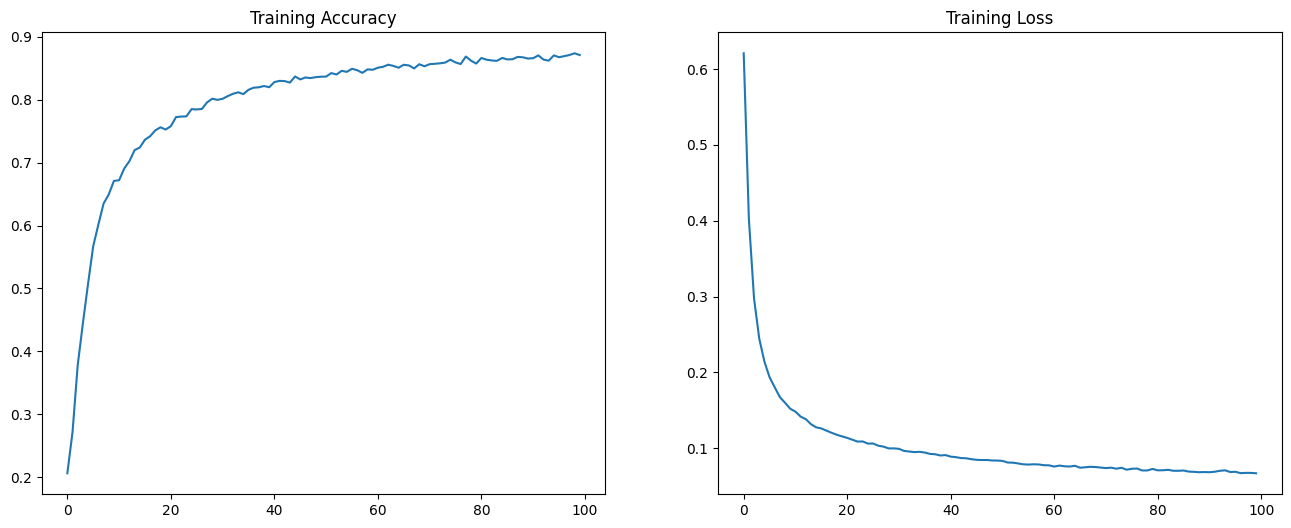

In [26]:
# history contains the training information about accuracy and loss in every epoch
print(history.history.keys())

figure = plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Training Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.show()

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[[ 93  59  47   0   0   0   0  35   0   0  19   1]
 [ 91  39  69   0   0   0   0   0   0   1  54   0]
 [  0  20 169   0   0   0   0   0   0  13  52   0]
 [  0   3   0 210   0   0   0  21   7   4   9   0]
 [  0   5   0   0 239   0   0   0   0   0   9   1]
 [  0   3   0   0   0 223   0   0   0   0  28   0]
 [  0   4   0   1   0   0 199   0  26   4  20   0]
 [  0   6   1  22   0   0   0 199   3   0  23   0]
 [  0  12   1   1   0   0   0 124  89   1  26   0]
 [  0   0   0   1   0  14   1   2   0 219  17   0]
 [  0   6   0   0   0   0   0   0   3   0 245   0]
 [  0   0   0   7   2   0   3   0 176   1  28  37]]


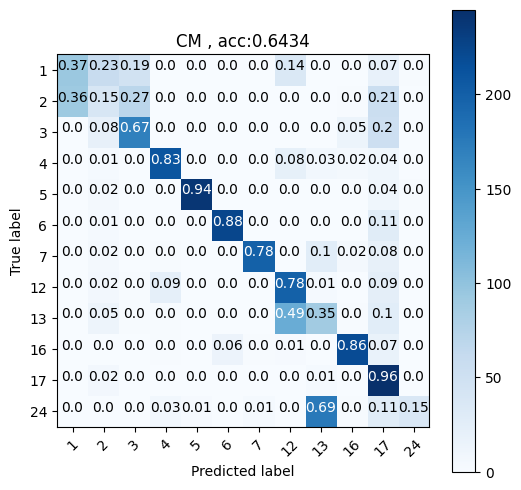

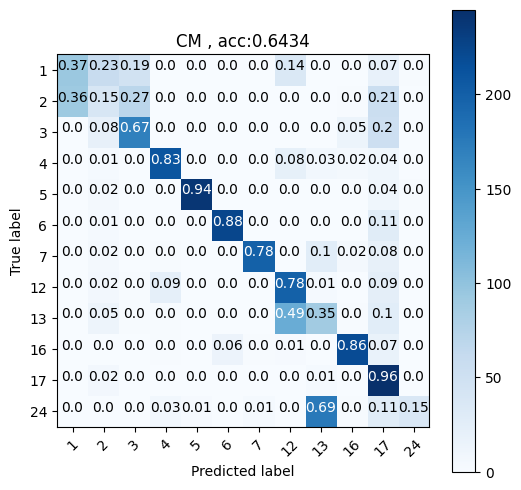

In [27]:
y_predict = model.predict(X_test)
acc_test = sum(y_test == np.argmax(y_predict, axis=1)) / y_test.shape[0]
y_test_cat = label2categorical(y_test,numClass)
# Convert back from categorical to numerical with np.argmax()
cm = skl.metrics.confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(y_predict, axis=1)) 
print(cm)
plot_confusion_matrix(cm, np.unique(y_test).astype('int'))

We can train the model for more epochs, just re-run the open loop training code block. Because the model is kept after model.fit(). You can compare the confusion matrix after more training epochs. Note this is not expected to be highly accurate because we are doing leave-person-out, so the model is being tested on a complete stranger to generate the confusion matrix.

But, we have no means of knowing when to stop training. So in deep learning there is a 'validation' process that can be included in the model.fit(). You SHOULD not use the testing data for validation, as that will be overfitting the training process for the testing data. We have person 1 as test, person 2-8 as training. We can use a random split among the training data to separate training and validation data.
Then we can stop the training process when we think the validation has reached a stable plateau number.
Be sure that training, validation and testing should not overlap.

In [30]:
X_fit = X_train
y_fit = y_train
X_train, X_valid, y_train, y_valid = train_test_split( # TODO
    # we want to have 90% of the X_fit and y_fit to be the training data, and the remaining 10% to be the validation data
    X_fit,
    y_fit,
    test_size=0.1,      # 10% validation
    random_state=42,    # reproducible split
    stratify=y_fit      # preserve class distribution                                       
)
print(y_train.shape)
print(y_valid.shape)
# make sure no classes are left out in the validation data
print(np.unique(y_train))
print(np.unique(y_valid))

(7489,)
(833,)
[ 1.  2.  3.  4.  5.  6.  7. 12. 13. 16. 17. 24.]
[ 1.  2.  3.  4.  5.  6.  7. 12. 13. 16. 17. 24.]


expected output:


```
(4241,)
(472,)
[ 1.  2.  3.  4.  5.  6.  7. 12. 13. 16. 17. 24.]
[ 1.  2.  3.  4.  5.  6.  7. 12. 13. 16. 17. 24.]
```



In [33]:
model = build_CNN()

m_opt = keras.optimizers.Adam()

model.compile(
    optimizer=m_opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

epoch = 5000
batch = 200
patience = 100

modelfile = 'best_model.keras'

cb_checkpoint = keras.callbacks.ModelCheckpoint(
    modelfile,
    monitor='val_accuracy',
    mode='max',
    verbose=1,
    save_best_only=True
)

cb_earlystop = keras.callbacks.EarlyStopping(
    patience=patience,
    monitor='val_accuracy',
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    label2categorical(y_train, numClass),
    epochs=epoch,
    batch_size=batch,
    validation_data=(
        X_valid,
        label2categorical(y_valid, numClass)
    ),
    callbacks=[
        cb_checkpoint,
        cb_earlystop
    ],
    verbose=2
)

Epoch 1/5000

Epoch 1: val_accuracy improved from None to 0.28331, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
38/38 - 4s - 112ms/step - accuracy: 0.3333 - loss: 2.0753 - val_accuracy: 0.2833 - val_loss: 2.5190
Epoch 2/5000

Epoch 2: val_accuracy improved from 0.28331 to 0.33253, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
38/38 - 1s - 39ms/step - accuracy: 0.4706 - loss: 1.5889 - val_accuracy: 0.3325 - val_loss: 1.9918
Epoch 3/5000

Epoch 3: val_accuracy improved from 0.33253 to 0.37575, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
38/38 - 2s - 40ms/step - accuracy: 0.5567 - loss: 1.3500 - val_accuracy: 0.3758 - val_loss: 1.8056
Epoch 4/5000

Epoch 4: val_accuracy improved from 0.37575 to 0.47419, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
38/38 - 1s - 39ms/step - accuracy: 0.6030 - loss: 1.2086 - val_accuracy: 0.4742 - val

In [35]:
print(
    "Best Validation Accuracy:",
    max(history.history['val_accuracy'])
)

print(
    "Final Validation Accuracy:",
    history.history['val_accuracy'][-1]
)

print(
    "Test Accuracy:",
    acc_test
)

Best Validation Accuracy: 0.8871548771858215
Final Validation Accuracy: 0.8823529481887817
Test Accuracy: 0.04691601049868766


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


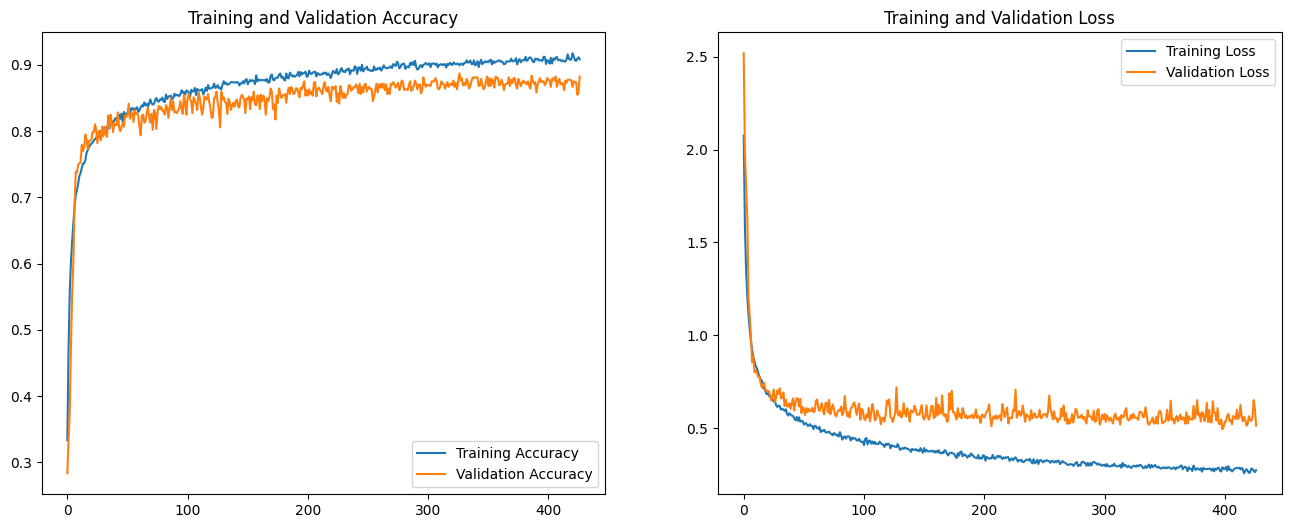

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[[138  62   5   0   0   0   0   1   0   1  13  34]
 [ 94  35  79   0   0   0   0   5   0   5  36   0]
 [  1  19 162   0   0   0   0  11   2  39  20   0]
 [  0   1   1 224   1   0   0  14   0   2  11   0]
 [  0   2   0   0 239   0   0   0   1   0  12   0]
 [  0   0   1   0   0 224   0   0   0   0  29   0]
 [  0   2   0   6   0   0 213   1   9   0  23   0]
 [  0   6   0  58   0   0   0 165   0   3  22   0]
 [  0   7   6   7   0   0   0 164  44   0  26   0]
 [  0   0   3   2   0   5   1   1   1 224  17   0]
 [  0   3   0   0   0   0   0   0   3   0 248   0]
 [  0   0   0   4  53   0  18   7 133   1  28  10]]


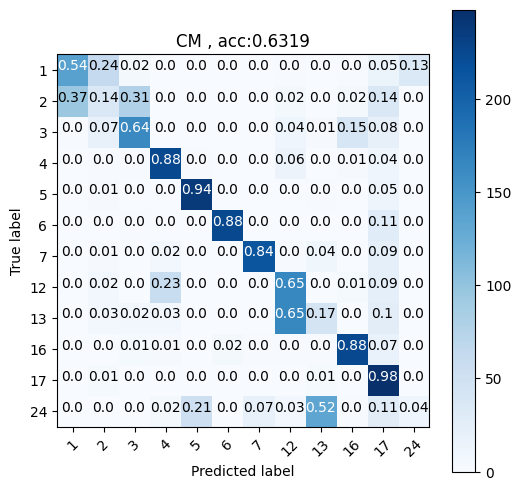

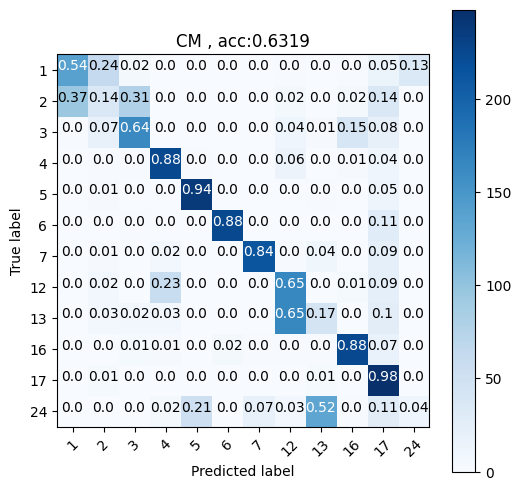

In [34]:
print(history.history.keys())
figure = plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

y_predict = model.predict(X_test)
acc_test = sum(y_test == np.argmax(y_predict, axis=1)) / y_test.shape[0]
y_test_cat = label2categorical(y_test,numClass)
cm = skl.metrics.confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(y_predict, axis=1))
print(cm)
plot_confusion_matrix(cm, np.unique(y_test).astype('int'))


# Epilogue

In this exercise we've seen how to classify activities from multi-channel temporal sensor data with (not so) deep neural networks.

The confusion matrix is not directly comparable with ex2, because in ex2 we did cross-validation with only one person's data, but here we have proper leave-person-out.

You can try modify the model structure, play around with the dimensions, or LSTM layers, and see if you can have different results.
You can see how different layers work in this documentation:
https://www.tensorflow.org/api_docs/python/tf/keras/layers
But it is only for your own interest, not in the scope of the exam.